## Todo 

The separation for galaxies and clusters is too large to be realistic. Check this. 

Create a covariance of number count errors.

In [21]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import healpy as hp
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

## Functions for computing spectroscopic richness and profiles
from projection_functions import *


##Plotting
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt

from astropy.io import ascii

plot_params = {

'axes.linewidth': 1.25,
'xtick.major.width': 1, 'ytick.major.width': 1,
'xtick.minor.width': 1, 'ytick.minor.width': 1,
'xtick.major.size': 12, 'ytick.major.size': 12,
'xtick.labelsize': 12, 'ytick.labelsize': 12,
'xtick.direction': 'in', 'ytick.direction': 'in',
'xtick.major.pad': 6, 'xtick.minor.pad': 6,
'figure.constrained_layout.use': True,
#'text.usetex': True,
'font.family': 'Serif',
'font.size': 14,
'legend.fontsize': 11
    
}
plt.rcParams.update(plot_params)

In [22]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo

In [23]:
with open('bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)

fcols = ['g','r','z','w1','w2']
for col in fcols:
    #bgs_matched['flux_'+col.lower()+'_dered'] = bgs_matched['FLUX_'+col]/data['MW_TRANSMISSION_'+col]
    bgs_matched['r_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_r_dered'])
    bgs_matched['g_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_g_dered'])
    bgs_matched['gmr'] = bgs_matched['g_dered']-bgs_matched['r_dered']

#binGap = 1e-5
wide_bin_1 = np.linspace(-0.1,-0.005,21, endpoint=False)
small_bin = np.linspace(-0.005,0.005,21, endpoint=False)
micro_bin = np.linspace(-0.005,0.005,31)
wide_bin_2 = np.linspace(0.005,0.1,21, endpoint=False)

binBoundaries = np.hstack((wide_bin_1, small_bin))
binBoundaries = np.hstack((binBoundaries, wide_bin_2))
binCent = np.asarray([(binBoundaries[i] + binBoundaries[i+1])/2 for i in range(len(binBoundaries)-1)])
binCent_micro = np.asarray([(micro_bin[i] + micro_bin[i+1])/2 for i in range(len(micro_bin)-1)])
bin_width = np.asarray([binBoundaries[i+1]-binBoundaries[i] for i in range(len(binBoundaries[:-1]))])

## None overlapping bins
assert len(set(binCent)) == len(binCent), "Overlapping bins"
assert len(set(binBoundaries)) == len(binBoundaries), "Overlapping bins"

In [24]:
def spherical_to_cartesian(ra, dec):
    """
    Calculate cartesian coordinates on a unit sphere given two angular coordinates.
    parameters

    Parameters
    -----------
    ra : array
        Angular coordinate in degrees

    dec : array
        Angular coordinate in degrees

    Returns
    --------
    x,y,z : sequence of arrays
        Cartesian coordinates.

    Examples
    ---------
    >>> ra, dec = 0.1, 1.5
    >>> x, y, z = spherical_to_cartesian(ra, dec)

    """

    rar = np.radians(ra)
    decr = np.radians(dec)

    x = np.cos(rar) * np.cos(decr)
    y = np.sin(rar) * np.cos(decr)
    z = np.sin(decr)

    return x, y, z

def haversine(lon1, lat1, lon2, lat2, r=1):
    """
    Calculate the great circle distance in kilometers between two points (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    return c*r

### Testing the radial dependence of aperture matched galaxies

In [25]:
bgs_matched = bgs_matched.to_pandas() ##Convert astropy table to pandas

## Find radial dependence of galaxies around clusters
smallz = bgs_matched.iloc[np.where(np.abs(bgs_matched['Z_BGS']-bgs_matched['Z_SPEC_x'])/(1+bgs_matched['Z_BGS']) < 0.1)[0]]
rm_z = smallz['Z_SPEC_x'].values * cu.redshift
rm_d = rm_z.to(u.Mpc, cu.redshift_distance(Planck18, kind="comoving"))
r_bgs = haversine(smallz['RA_BGS'], smallz['DEC_BGS'], smallz['RA_x'], \
              smallz['DEC_x'], r=rm_d)

##For redMapper candidates
rm_cand = smallz.iloc[np.where(smallz['DEC_y'] != -1.0)[0]]
rm_z = rm_cand['Z_SPEC_x'].values * cu.redshift
rm_d = rm_z.to(u.Mpc, cu.redshift_distance(Planck18, kind="comoving"))
r_RM = haversine(rm_cand['RA_y'], rm_cand['DEC_y'], rm_cand['RA_x'], \
              rm_cand['DEC_x'], r=rm_d)

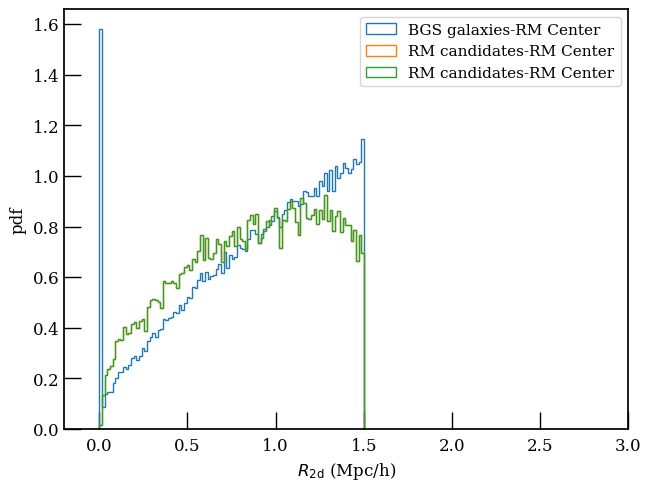

In [26]:
plt.hist(r_bgs, bins=100, histtype='step', label='BGS galaxies-RM Center', density=True)
plt.hist(r_RM, bins=100, histtype='step', label='RM candidates-RM Center', density=True)
plt.hist(r_RM, bins=100, histtype='step', label='RM candidates-RM Center', density=True)
plt.ylabel(r'pdf', fontsize=12)
plt.xlabel(r'$R_{\rm 2d}$ (Mpc/h)', fontsize=12)
plt.legend()
plt.xlim((-0.2,3))
plt.show()

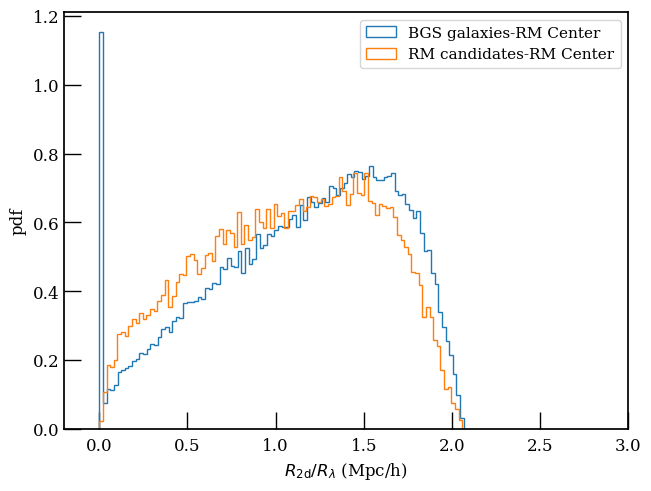

In [27]:
## Normalized by redMaPPer radius
plt.hist(r_bgs/smallz['R_LAMBDA'], bins=100, histtype='step', label='BGS galaxies-RM Center', density=True)
plt.hist(r_RM/rm_cand['R_LAMBDA'], bins=100, histtype='step', label='RM candidates-RM Center', density=True)
plt.ylabel(r'pdf', fontsize=12)
plt.xlabel(r'$R_{\rm 2d}/R_{\lambda}$ (Mpc/h)', fontsize=12)
plt.legend()
plt.xlim((-0.2,3))
plt.show()

## Splitting galaxies by radial bins

In [28]:
# ------------------------------------------------------------
# Column name configuration (ADJUST TO YOUR CATALOG)
# ------------------------------------------------------------

COL_CLUS_ID   = "ID"             # unique cluster ID
COL_CLUS_Z    = "Z_SPEC_x"       # cluster redshift (or spec-z)
COL_CLUS_RA   = 'RA_x'
COL_CLUS_DEC  = 'DEC_x'
COL_GAL_RA    = 'RA_BGS'
COL_GAL_DEC   = 'DEC_BGS'
COL_RLAMBDA   = "R_LAMBDA"       # redMaPPer radius, same units as R_proj
COL_LAMBDA    = "LAMBDA"         # cluster richness
COL_GAL_Z     = "Z_BGS"         # galaxy spectroscopic redshift
COL_R_PROJ    = "R_proj"         # projected separation cluster–galaxy (same units as R_lambda)
COL_R_NORM    = 'R_norm'

# ------------------------------------------------------------
# Select member galaxies: |z_gal - z_clus| <= 0.01
# ------------------------------------------------------------
dz_max = 0.01
bgs_nonproj = bgs_matched.iloc \
        [np.where(np.abs(bgs_matched[COL_GAL_Z]-bgs_matched[COL_CLUS_Z])/(1+bgs_matched[COL_GAL_Z]) < dz_max)].copy()

print(f"Total pairs: {len(bgs_matched)}, members after dz cut: {len(bgs_nonproj)}")

# ------------------------------------------------------------
# Compute projected distance
# ------------------------------------------------------------
cl_coord = SkyCoord(ra=bgs_nonproj[COL_CLUS_RA].values * u.deg, dec=bgs_nonproj[COL_CLUS_DEC].values * u.deg)
gal_coord = SkyCoord(ra=bgs_nonproj[COL_GAL_RA].values * u.deg, dec=bgs_nonproj[COL_GAL_DEC].values * u.deg)

# 2. Angular separation (returns angle quantity)
sep = (cl_coord.separation(gal_coord)).to(u.rad).value

# 3. Angular diameter distance at cluster redshift
#    (broadcasts over the array of z_cl)
DA = cosmo.angular_diameter_distance(bgs_nonproj[COL_CLUS_Z]).values  # [Mpc]

# 4. Physical projected distance R_proj = D_A(z_cl) * theta
R_proj = DA * sep  # result: Quantity in Mpc

# Store as float
bgs_nonproj[COL_R_PROJ] = R_proj
# ------------------------------------------------------------
# Compute normalized radius r / R_lambda
# ------------------------------------------------------------
bgs_nonproj[COL_R_NORM] = bgs_nonproj[COL_R_PROJ].values / bgs_nonproj[COL_RLAMBDA].values

Total pairs: 111602, members after dz cut: 50981


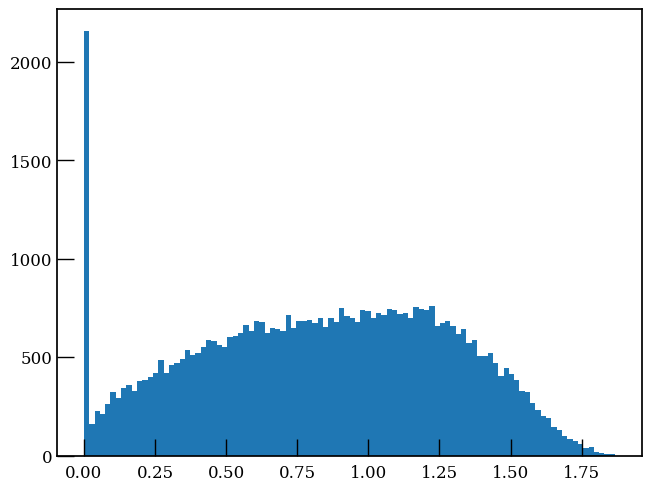

In [29]:
plt.hist(bgs_nonproj[COL_R_NORM], bins=100)
plt.show()

### Create radial bins. 

In [30]:
# ------------------------------------------------------------
# Define radial bins in r/R_lambda and richness bins in lambda
# ------------------------------------------------------------
# Example edges – change as you like

radial_bins = np.array([0.0, 0.01, 0.1, 0.2, 0.3, 0.6, 1.0, 2.0])   # r / R_lambda
lambda_bins = np.array([20, 30, 40, 60, 80, 200])      # lambda

# Label helper for nicer column names later
def radial_bin_label(i):
    r_in  = radial_bins[i]
    r_out = radial_bins[i+1]
    return f"rnorm_{r_in:.2f}_{r_out:.2f}"

In [31]:
# ------------------------------------------------------------
# Assign each galaxy to a radial bin
# ------------------------------------------------------------

# digitize returns bin index in [1, nbins]; subtract 1 → [0, nbins-1]
bgs_nonproj["rad_bin"] = np.digitize(bgs_nonproj[COL_R_NORM], bins=radial_bins) - 1
bgs_nonproj["lambda_bin"] = np.digitize(bgs_nonproj[COL_LAMBDA], bins=lambda_bins) - 1

# Keep only galaxies that actually fall inside the radial and richness bins
n_rad_bins = len(radial_bins) - 1
valid = (bgs_nonproj["rad_bin"] >= 0) & (bgs_nonproj["rad_bin"] < n_rad_bins)

n_lambda_bins = len(lambda_bins) - 1
valid &= (bgs_nonproj["lambda_bin"] >= 0) & (bgs_nonproj["lambda_bin"] < n_lambda_bins)
bgs_nonproj = bgs_nonproj[valid].copy()

In [32]:
# ------------------------------------------------------------
# Count galaxies per cluster per radial bin
# ------------------------------------------------------------

# Group by cluster + radial bin and count
cluster_rad_counts = (
    bgs_nonproj
    .groupby(["lambda_bin","rad_bin"])
    .size()
    .unstack("rad_bin", fill_value=0)
)

In [33]:
cluster_rad_counts

rad_bin,0,1,2,3,4,5,6
lambda_bin,,,,,,,
0,1209,503,848,1064,4185,6621,10646
1,514,256,470,575,2258,3608,5072
2,296,168,314,433,1705,2854,3194
3,63,62,100,136,523,920,806
4,28,33,48,68,328,623,384


## Todo:
1. Divide by number of clusters to get mean count.
2. Jackknife errors. To do so you will need the to perform cluster_rad_counts after N-1 removal. 

In [80]:
bgs_nonproj.columns

Index(['TARGETID', 'RA_BGS', 'DEC_BGS', 'Z_BGS', 'WEIGHT', 'flux_g_dered',
       'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered', 'ID',
       'LAMBDA', 'Z_LAMBDA', 'R_LAMBDA', 'Z_SPEC_x', 'RA_x', 'DEC_x',
       'MODEL_MAG_R_x', 'MODEL_MAGERR_R_x', 'RM_gal_flag', 'Z_SPEC_y', 'RA_y',
       'DEC_y', 'R', 'P', 'MODEL_MAG_R_y', 'MODEL_MAGERR_R_y', 'central_flag',
       'geoFrac', 'r_dered', 'g_dered', 'gmr', 'R_proj', 'R_norm', 'rad_bin',
       'lambda_bin'],
      dtype='object')

In [35]:
import numpy as np
import pandas as pd
from typing import Union

import numpy as np
import pandas as pd

def cov_to_corr(cov: pd.DataFrame) -> pd.DataFrame:
    """
    Convert covariance matrix (DataFrame) to correlation matrix.
    """
    diag = np.sqrt(np.diag(cov))
    denom = np.outer(diag, diag)
    corr = np.zeros_like(cov)          # default = 0
    mask = denom > 0                 # only where correlation is defined
    corr[mask] = cov[mask] / denom[mask]

    return corr

def jackknife_cov_counts(
    df: pd.DataFrame,
    lambda_col: str = "lambda_bin",
    rad_col: str = "rad_bin",
    jk_col: str = "ID", #Each Cluster is a JK region
    weight_col: Union[str, None] = None,
    fill_value: float = 0.0,
):
    """
    Build jackknife covariance of galaxy counts per cluster across radial bins, separately per lambda_bin.

    Returns
    -------
    cov_by_lambda : dict
        {lambda_bin_value: covariance_dataframe} with index/columns = rad_bin
    mean_by_lambda : dict
        {lambda_bin_value: mean_vector_series} mean counts per rad_bin
    loo_by_lambda : dict
        {lambda_bin_value: loo_dataframe} rows=jk omit index (each row is leave-one-out estimate), cols=rad_bin
    """
    required = {lambda_col, rad_col, jk_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Define the estimator for "counts" per (lambda, jk, rad)
    if weight_col is None:
        g = df.groupby([lambda_col, jk_col, rad_col]).size()
    else:
        if weight_col not in df.columns:
            raise ValueError(f"weight_col='{weight_col}' not in df.columns")
        g = df.groupby([lambda_col, jk_col, rad_col])[weight_col].sum()

    g = g.rename("count").reset_index()

    # Wide table: rows = (lambda_bin, jk_id), columns = rad_bin
    wide = (
        g.pivot_table(index=[lambda_col, jk_col], columns=rad_col, values="count", fill_value=fill_value)
        .sort_index(axis=1)
    )

    corr_by_lambda = {}
    cov_by_lambda = {}
    mean_by_lambda = {}
    loo_by_lambda = {}

    # Process each lambda_bin separately
    for lam_val, sub in wide.groupby(level=0):
        # sub index is MultiIndex (lambda_bin, jk_id); drop lambda level for convenience
        X = sub.droplevel(0)  # rows=jk_id, cols=rad_bin
        rad_bins = X.columns

        # Need at least 2 jackknife regions to form covariance
        N = X.shape[0]
        if N < 2:
            cov_by_lambda[lam_val] = pd.DataFrame(
                np.nan, index=rad_bins, columns=rad_bins
            )
            mean_by_lambda[lam_val] = pd.Series(np.nan, index=rad_bins, name="mean")
            loo_by_lambda[lam_val] = X
            continue

        # Leave-one-out estimates for each jackknife omission:
        # If X_j is the counts in region j, then the leave-one-out total is (sum_all - X_j).
        # This is usually what you want for number-count profiles.
        S = X.sum(axis=0)
        loo = (S - X)/N  # DataFrame, rows=jk_id (omitted), cols=rad_bin

        # Jackknife mean (over LOO replicates)
        mu = loo.mean(axis=0)

        # Jackknife covariance: (N-1)/N * sum_i (x_i - mu)(x_i - mu)^T
        D = loo - mu
        cov = (N - 1) / N * (D.to_numpy().T @ D.to_numpy())
        corr = cov_to_corr(cov)

        cov_df = pd.DataFrame(cov, index=rad_bins, columns=rad_bins)
        corr_df = pd.DataFrame(corr, index=rad_bins, columns=rad_bins)
        cov_by_lambda[lam_val] = cov_df
        corr_by_lambda[lam_val] = corr_df
        mean_by_lambda[lam_val] = mu.rename("mean")
        loo_by_lambda[lam_val] = loo

    return corr_by_lambda, cov_by_lambda, mean_by_lambda, loo_by_lambda


In [110]:
corr_by_lambda, cov_by_lambda, mean_by_lambda, loo_by_lambda = \
    jackknife_cov_counts(
    bgs_nonproj,
    lambda_col ="lambda_bin",
    rad_col ="rad_bin",
    jk_col = "ID",
    weight_col = 'WEIGHT',
    fill_value = 0.0,
    )

corr_by_lambda_noweight, cov_by_lambda_noweight, mean_by_lambda_noweight, loo_by_lambda_noweight = \
    jackknife_cov_counts(
    bgs_nonproj,
    lambda_col ="lambda_bin",
    rad_col ="rad_bin",
    jk_col = "ID",
    weight_col = None,
    fill_value = 0.0,
    )

In [104]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm

def signed_log(x, x0):
    return np.sign(x) * np.log10(1 + np.abs(x) / x0)

def plot_cov(
    cov,
    ax=None,
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    title=None,
    cbar_label=None,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure

    #x0 = np.median(np.abs(np.diag(cov)))  # scale ~ typical variance
    #cov_slog = signed_log(cov, x0)

    norm = SymLogNorm(
    linthresh=1e-2,
    linscale=1,
    vmin=np.min(cov),
    vmax= np.max(cov)
)
    
    im = ax.imshow(
        cov,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        #norm=norm,
        aspect="auto",
    )

    cbar = fig.colorbar(im, ax=ax, label="Covariance")
    if cbar_label:
        cbar.set_label(cbar_label)

    if title:
        ax.set_title(title)

    ax.set_xlabel("Radial bin")
    ax.set_ylabel("Radial bin")

    return im, ax


def plot_corr(
    corr,
    ax=None,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    title=None,
    cbar_label=None,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure

    #x0 = np.median(np.abs(np.diag(cov)))  # scale ~ typical variance
    #cov_slog = signed_log(cov, x0)
    
    im = ax.imshow(
        corr,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        #norm=LogNorm(vmin=np.min(cov[cov > 0]), vmax=np.max(cov)),
        aspect="auto",
    )

    cbar = fig.colorbar(im, ax=ax, label="Correlation")
    if cbar_label:
        cbar.set_label(cbar_label)

    if title:
        ax.set_title(title)

    ax.set_xlabel("Radial bin")
    ax.set_ylabel("Radial bin")

    return im, ax



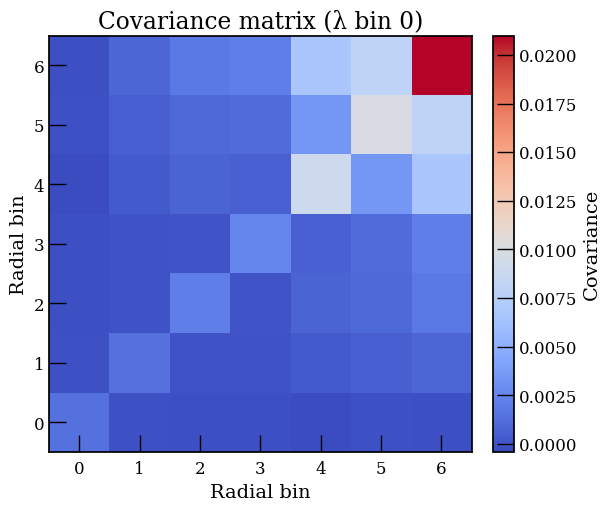

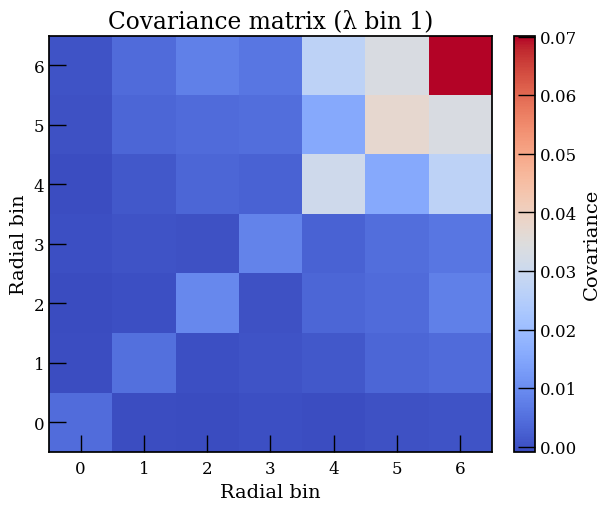

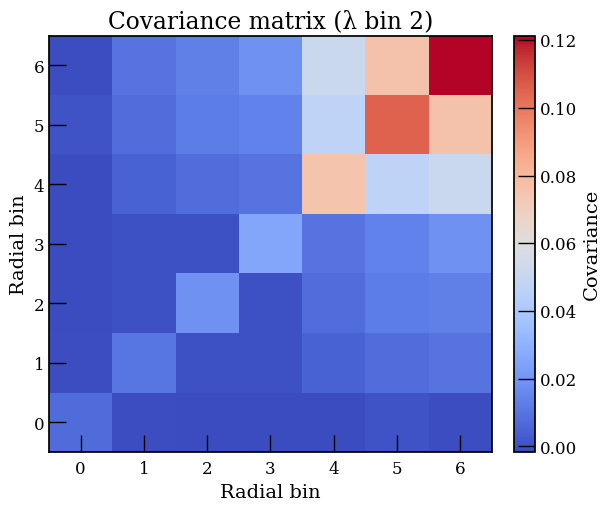

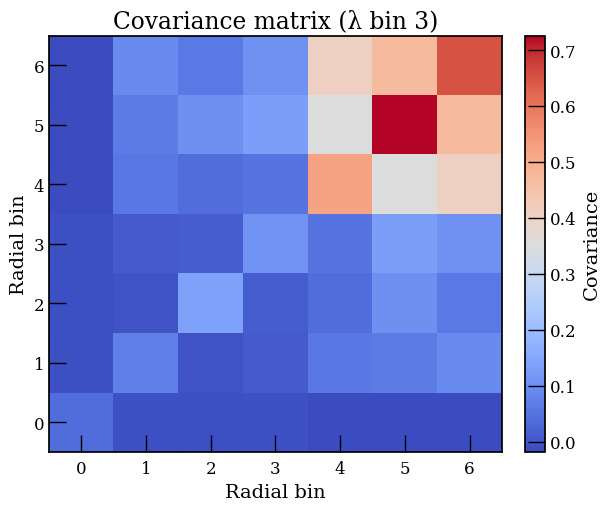

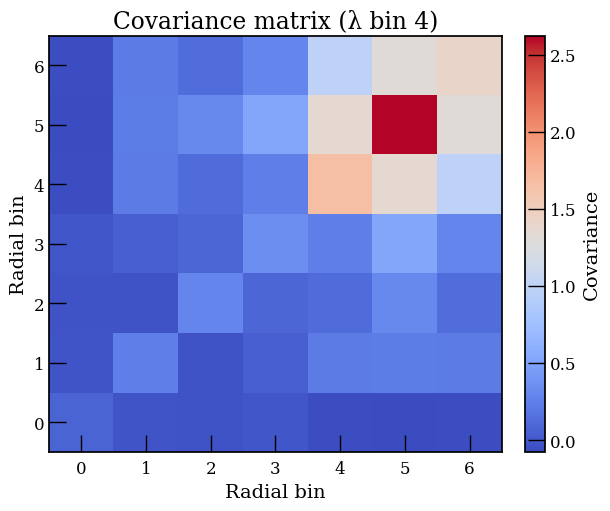

In [111]:
for lambda_bin, cov_bin in cov_by_lambda.items():
    #fig, ax = plt.subplots(figsize=(6, 5))
    title = f"Covariance matrix (λ bin {lambda_bin})"
    im, ax = plot_cov(cov_bin, title = title)
    plt.show()

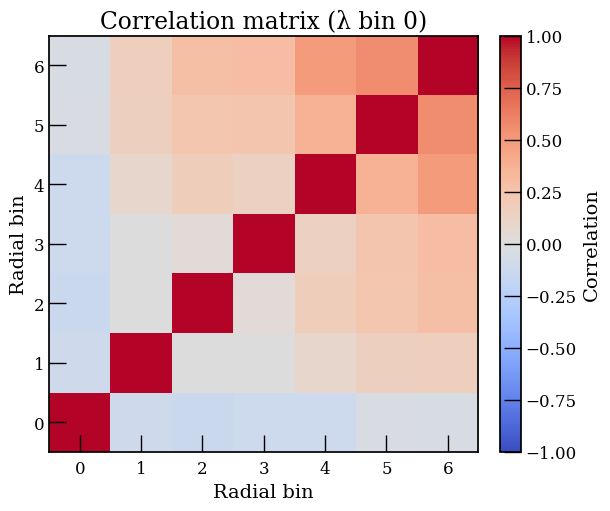

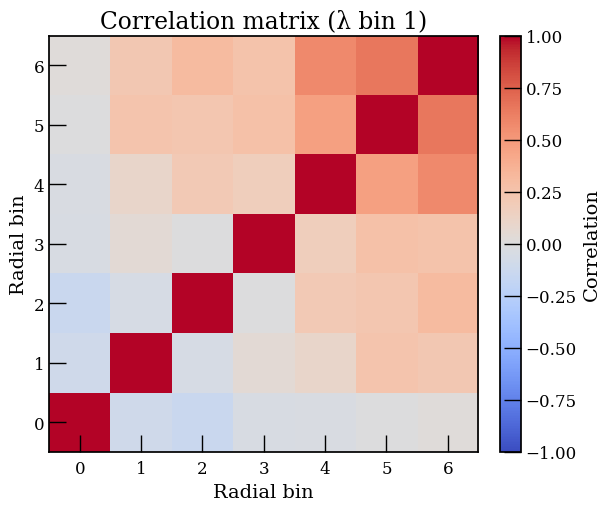

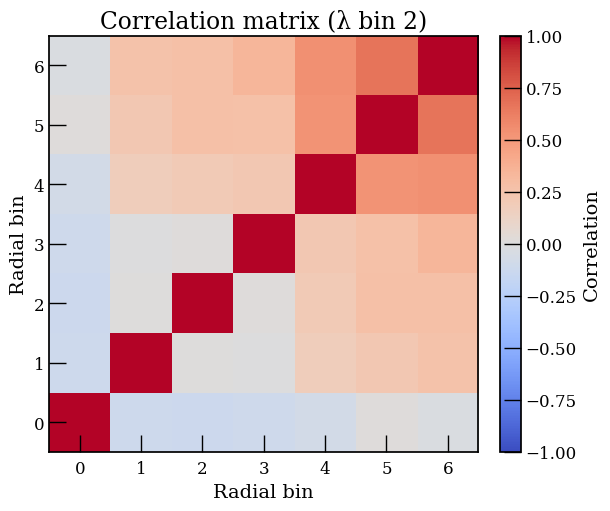

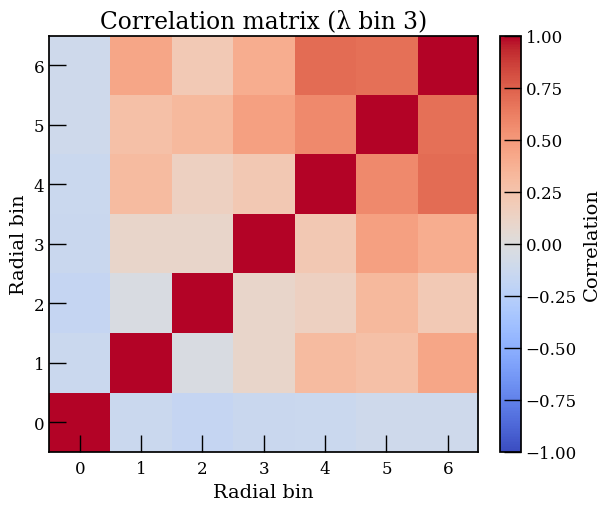

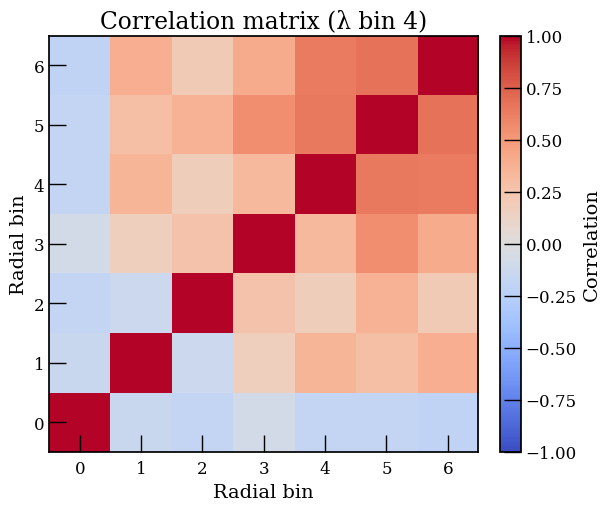

In [112]:
for lambda_bin, corr_bin in corr_by_lambda.items():
    #fig, ax = plt.subplots(figsize=(6, 5))
    title = f"Correlation matrix (λ bin {lambda_bin})"
    im, ax = plot_corr(corr_bin, title = title)
    plt.show()

In [113]:
cov_by_lambda[0]

rad_bin,0,1,2,3,4,5,6
rad_bin,,,,,,,
0,0.001453,-1.471039e-04,-0.000222,-2.156012e-04,-0.000414,-0.000121,-0.000228
1,-0.000147,1.433383e-03,-0.000003,-4.862104e-07,0.000326,0.000582,0.000862
2,-0.000222,-2.618583e-06,0.002124,7.732650e-05,0.000785,0.001042,0.001908
3,-0.000216,-4.862104e-07,0.000077,2.515904e-03,0.000653,0.001173,0.002131
4,-0.000414,3.257831e-04,0.000785,6.526430e-04,0.009103,0.003441,0.006712
5,-0.000121,5.820304e-04,0.001042,1.172667e-03,0.003441,0.009886,0.008060
6,-0.000228,8.617230e-04,0.001908,2.130545e-03,0.006712,0.008060,0.020987


In [114]:
lambda_bins

array([0, 1, 2, 3, 4, 5, 6])

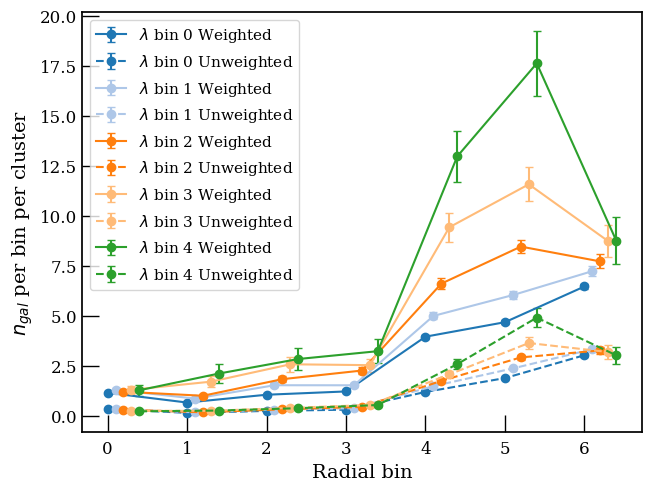

In [120]:
colors = plt.cm.tab20.colors
radial_bin_ind = np.arange(len(radial_bins)-1)
shift = 0.0
for lambda_bin, mean_bin in mean_by_lambda.items():
    color = colors[lambda_bin % len(colors)]
    #fig, ax = plt.subplots(figsize=(6, 5))
    variance = np.diag(cov_by_lambda[lambda_bin])
    stddev = np.sqrt(variance)
    plt.errorbar(radial_bin_ind+shift, mean_bin, label=f'$\lambda$ bin {lambda_bin} Weighted', \
                 yerr=stddev, linestyle='solid', marker='o', capsize=3, color=color)

    variance_noweight = np.diag(cov_by_lambda_noweight[lambda_bin])
    stddev_noweight = np.sqrt(variance_noweight)
    plt.errorbar(radial_bin_ind+shift, mean_by_lambda_noweight[lambda_bin], label=f'$\lambda$ bin {lambda_bin} Unweighted', \
                 yerr=stddev_noweight, linestyle='--', marker='o', capsize=3, color=color)

    shift += 0.1

plt.xlabel(r'Radial bin')
plt.ylabel(r'$n_{gal}$ per bin per cluster')
plt.legend()
plt.show()

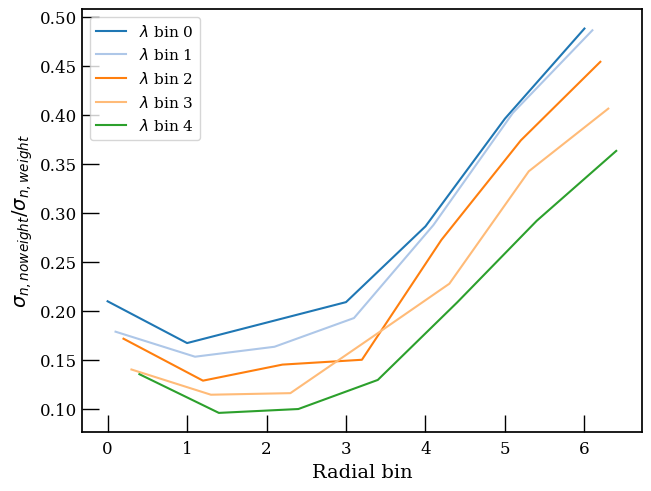

In [121]:
colors = plt.cm.tab20.colors
radial_bin_ind = np.arange(len(radial_bins)-1)
shift = 0.0
for lambda_bin, mean_bin in mean_by_lambda.items():
    color = colors[lambda_bin % len(colors)]
    #fig, ax = plt.subplots(figsize=(6, 5))
    variance = np.diag(cov_by_lambda[lambda_bin])
    stddev = np.sqrt(variance)
    variance_noweight = np.diag(cov_by_lambda_noweight[lambda_bin])
    stddev_noweight = np.sqrt(variance_noweight)

    
    plt.plot(radial_bin_ind+shift, stddev_noweight/stddev, label=f'$\lambda$ bin {lambda_bin}', color=color)

    shift += 0.1

plt.xlabel(r'Radial bin')
plt.ylabel(r'$\sigma_{n, noweight}/\sigma_{n, weight}$')
plt.legend()
plt.show()